In [2]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0,os.path.join(os.path.dirname(os.path.abspath('__file__')),'..', 'scripts'))
from db_connect import get_connection

conn = get_connection()
df = pd.read_sql_query("SELECT * FROM games", conn)
conn.close()

print(f"Total Games: {len(df)}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nShape: {df.shape}")

Total Games: 100

Columns: ['game_id', 'name', 'release_year', 'era', 'developer', 'publisher', 'game_type', 'genre', 'platform', 'budget', 'budget_status', 'file_size', 'peak_team_size', 'development_time', 'engine', 'franchise_name', 'metacritic_score', 'created_at']

Shape: (100, 18)


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   game_id           100 non-null    str    
 1   name              100 non-null    str    
 2   release_year      100 non-null    int64  
 3   era               100 non-null    str    
 4   developer         100 non-null    str    
 5   publisher         100 non-null    str    
 6   game_type         100 non-null    str    
 7   genre             100 non-null    str    
 8   platform          100 non-null    str    
 9   budget            46 non-null     float64
 10  budget_status     100 non-null    str    
 11  file_size         100 non-null    float64
 12  peak_team_size    96 non-null     float64
 13  development_time  99 non-null     float64
 14  engine            100 non-null    str    
 15  franchise_name    100 non-null    str    
 16  metacritic_score  89 non-null     float64
 17  created_a

In [4]:
df.describe()

,release_year,budget,file_size,peak_team_size,development_time,metacritic_score
count,100.000000,4.600000e+01,100.00000,96.000000,99.000000,89.000000
mean,2009.180000,4.475352e+07,16804.95750,92.250000,41.272727,88.988764
std,9.920268,6.065666e+07,31158.57556,149.699348,22.259517,4.701292
min,1980.000000,5.000000e+03,0.02000,1.000000,5.000000,76.000000
25%,2002.000000,1.050000e+07,500.00000,11.500000,24.000000,86.000000
50%,2010.000000,2.100000e+07,4000.00000,50.000000,36.000000,89.000000
75%,2017.250000,5.750000e+07,13250.00000,100.000000,50.000000,92.000000
max,2024.000000,3.160000e+08,154000.00000,1000.000000,108.000000,97.000000


In [5]:
df[df['development_time'] == df['development_time'].max()][['name','development_time']]

,name,development_time
55,Team Fortress 2,108.0


In [6]:
df.nlargest(5,'file_size')[['name','file_size','release_year']]

,name,file_size,release_year
71,Helldivers 2,154000.0,2024
20,Microsoft Flight Simulator,150000.0,2020
48,Black Myth: Wukong,118000.0,2024
11,GTA V,100000.0,2013
19,Baldur's Gate 3,100000.0,2023


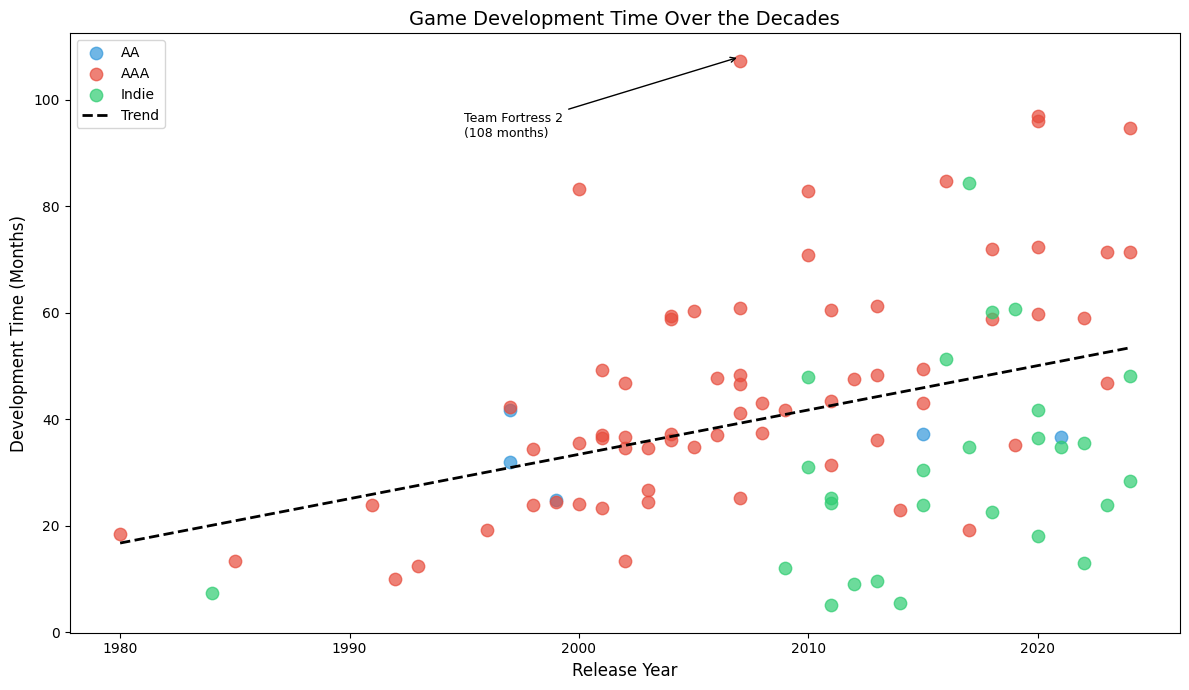

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

q1_df = df.dropna(subset=['development_time','release_year'])
plt.figure(figsize=(12, 7))

colors = {'AAA': '#e74c3c', 'AA': '#3498db', 'Indie': '#2ecc71'}

for game_type, group in q1_df.groupby('game_type'):
    jitter = np.random.uniform(-1.5, 1.5, size=len(group))
    plt.scatter(group['release_year'], group['development_time'] + jitter,
                c=colors[game_type], label=game_type, alpha=0.7, s=80)

# Trend line
z = np.polyfit(q1_df['release_year'], q1_df['development_time'], 1)
p = np.poly1d(z)
x_line = np.linspace(q1_df['release_year'].min(), q1_df['release_year'].max(), 100)
plt.plot(x_line, p(x_line), 'k--', linewidth=2, label='Trend')

tf2 = q1_df[q1_df['name'] == 'Team Fortress 2'].iloc[0]
plt.annotate('Team Fortress 2\n(108 months)', 
             xy=(tf2['release_year'], tf2['development_time']),
             xytext=(tf2['release_year'] - 12, tf2['development_time'] - 15),
             fontsize=9,
             arrowprops=dict(arrowstyle='->', color='black'))

plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Development Time (Months)', fontsize=12)
plt.title('Game Development Time Over the Decades', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/charts/q1_dev_time_over_years.png', dpi=150)
plt.show()

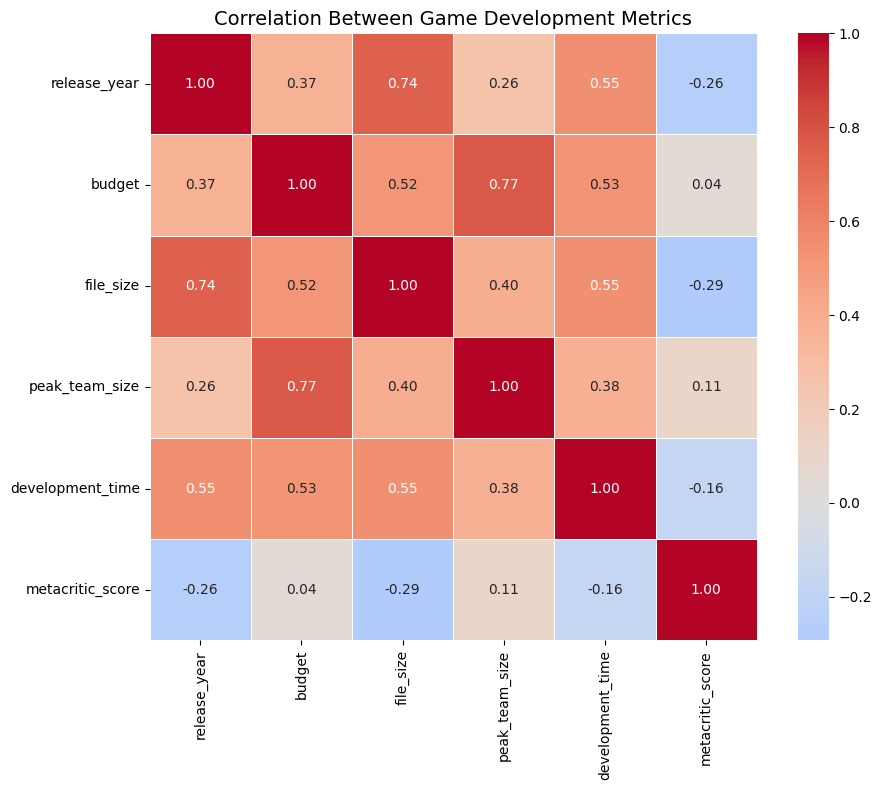

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = ['release_year','budget','file_size','peak_team_size','development_time','metacritic_score']

corr_df = df[numerical_cols].dropna()

plt.figure(figsize=(10,8))
sns.heatmap(corr_df.corr(),
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidth=0.5)
plt.title('Correlation Between Game Development Metrics',fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/charts/q2_correlation_heatmap.png',dpi=150)


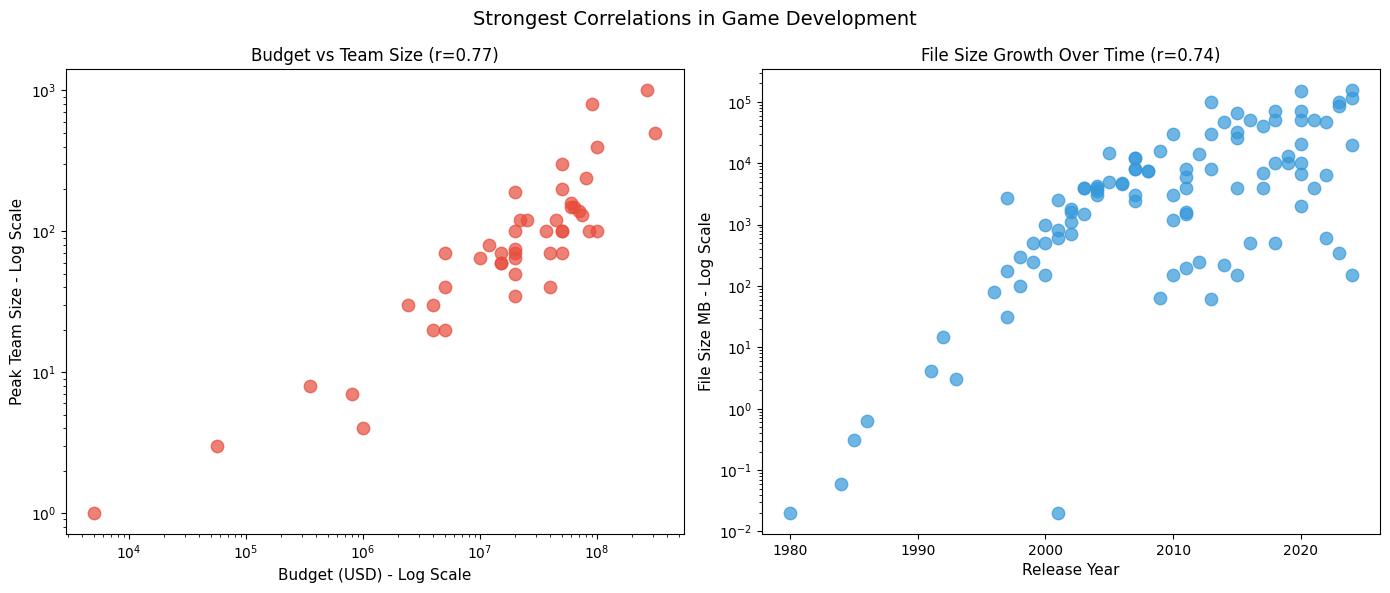

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Budget vs Team Size - log scale
q2_df = df.dropna(subset=['budget', 'peak_team_size'])
axes[0].scatter(q2_df['budget'], q2_df['peak_team_size'], 
                alpha=0.7, color='#e74c3c', s=80)
axes[0].set_yscale('log')
axes[0].set_xscale('log')
axes[0].set_xlabel('Budget (USD) - Log Scale', fontsize=11)
axes[0].set_ylabel('Peak Team Size - Log Scale', fontsize=11)
axes[0].set_title('Budget vs Team Size (r=0.77)', fontsize=12)

# File Size vs Release Year - log scale
q2_df2 = df.dropna(subset=['file_size', 'release_year'])
q2_df2 = q2_df2[q2_df2['file_size'] > 0]
axes[1].scatter(q2_df2['release_year'], q2_df2['file_size'], 
                alpha=0.7, color='#3498db', s=80)
axes[1].set_yscale('log')
axes[1].set_xlabel('Release Year', fontsize=11)
axes[1].set_ylabel('File Size MB - Log Scale', fontsize=11)
axes[1].set_title('File Size Growth Over Time (r=0.74)', fontsize=12)

plt.suptitle('Strongest Correlations in Game Development', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/charts/q2_scatter_correlations.png', dpi=150)
plt.show()

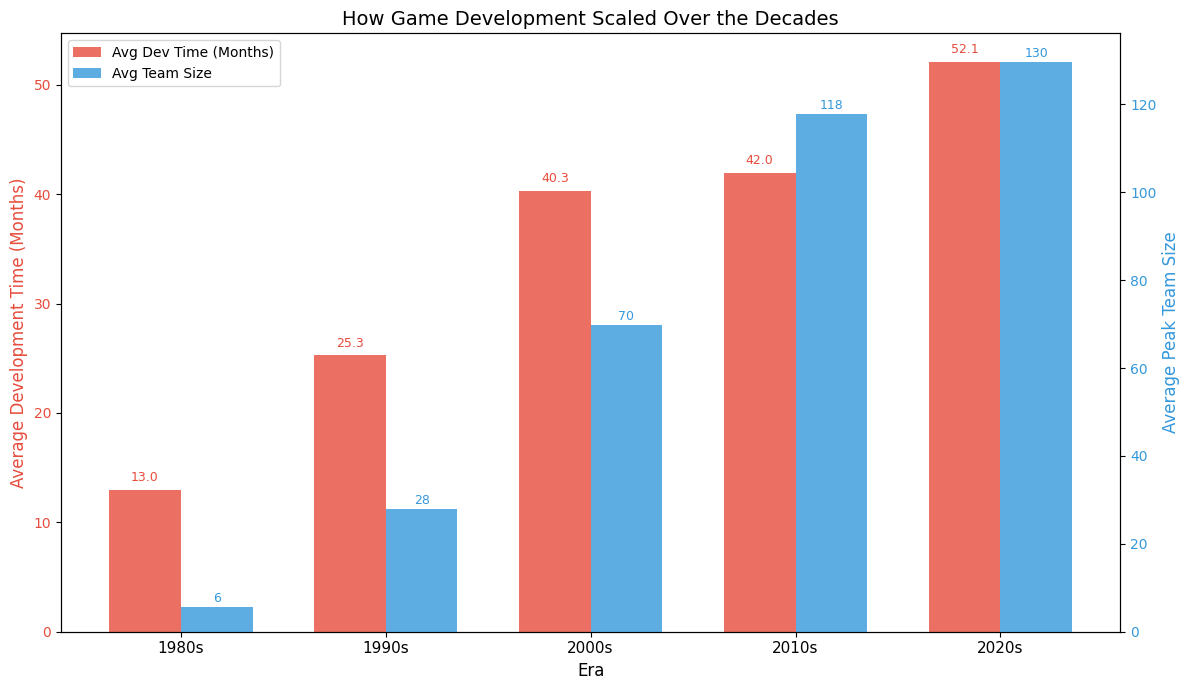

In [10]:
q3_df = df.dropna(subset=['development_time', 'peak_team_size'])

era_order = ['1980s', '1990s', '2000s', '2010s', '2020s']
era_dev_time = q3_df.groupby('era')['development_time'].mean().reindex(era_order)
era_team_size = q3_df.groupby('era')['peak_team_size'].mean().reindex(era_order)

x = np.arange(len(era_order))
width = 0.35

fig, ax1 = plt.subplots(figsize=(12, 7))

bars1 = ax1.bar(x - width/2, era_dev_time, width, 
                label='Avg Dev Time (Months)', color='#e74c3c', alpha=0.8)
ax1.set_xlabel('Era', fontsize=12)
ax1.set_ylabel('Average Development Time (Months)', fontsize=12, color='#e74c3c')
ax1.tick_params(axis='y', labelcolor='#e74c3c')

ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, era_team_size, width, 
                label='Avg Team Size', color='#3498db', alpha=0.8)
ax2.set_ylabel('Average Peak Team Size', fontsize=12, color='#3498db')
ax2.tick_params(axis='y', labelcolor='#3498db')

for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{bar.get_height():.1f}', ha='center', va='bottom', 
             fontsize=9, color='#e74c3c')

for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{bar.get_height():.0f}', ha='center', va='bottom', 
             fontsize=9, color='#3498db')

ax1.set_xticks(x)
ax1.set_xticklabels(era_order, fontsize=11)
ax1.set_title('How Game Development Scaled Over the Decades', fontsize=14)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('../outputs/charts/q3_era_dev_time_team_size.png', dpi=150)
plt.show()

/tmp/ipykernel_6988/731769321.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=q4_df,x='ip_type',y='budget',


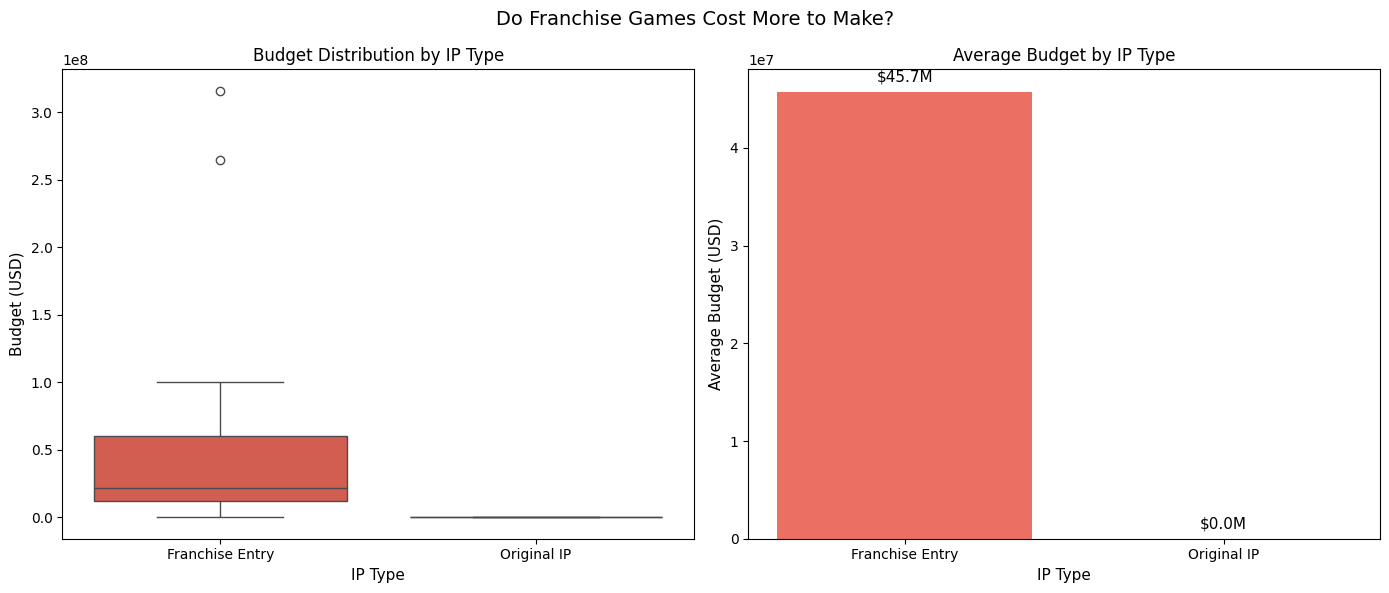

In [11]:
q4_df = df.dropna(subset=['budget'])
q4_df = q4_df.copy()

q4_df['ip_type'] = q4_df['franchise_name'].apply(
    lambda x: 'Original IP' if x == 'Standalone' else 'Franchise Entry'
)

fig,axes = plt.subplots(1,2,figsize=(14,6))

sns.boxplot(data=q4_df,x='ip_type',y='budget',
            palette={'Original IP': '#2ecc71','Franchise Entry' : '#e74c3c'},
            ax=axes[0])
axes[0].set_title('Budget Distribution by IP Type',fontsize=12)
axes[0].set_xlabel('IP Type',fontsize=11)
axes[0].set_ylabel('Budget (USD)',fontsize=11)

avg_budget =  q4_df.groupby('ip_type')['budget'].mean()
axes[1].bar(avg_budget.index,avg_budget.values,
            color=['#e74c3c','#2ecc71'],alpha=0.8)
for i, (idx,val) in enumerate(avg_budget.items()):
    axes[1].text(i,val + 1000000, f'${val/1e6:.1f}M',
                 ha='center',fontsize=11)

axes[1].set_title('Average Budget by IP Type',fontsize=12)
axes[1].set_xlabel('IP Type',fontsize=11)
axes[1].set_ylabel('Average Budget (USD)',fontsize=11)

plt.suptitle('Do Franchise Games Cost More to Make?',fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/charts/q4_franchise_vs_original_budget.png',dpi=150)
plt.show()

## Q4 - Franchise vs Original IP Budget
Skipped due to insufficient data. Only 1 Original IP game has confirmed budget data out of 46 total budget entries. 
This comparison requires more Original IP budget data to be meaningful.
Will revisit when dataset expands beyond 100 games.

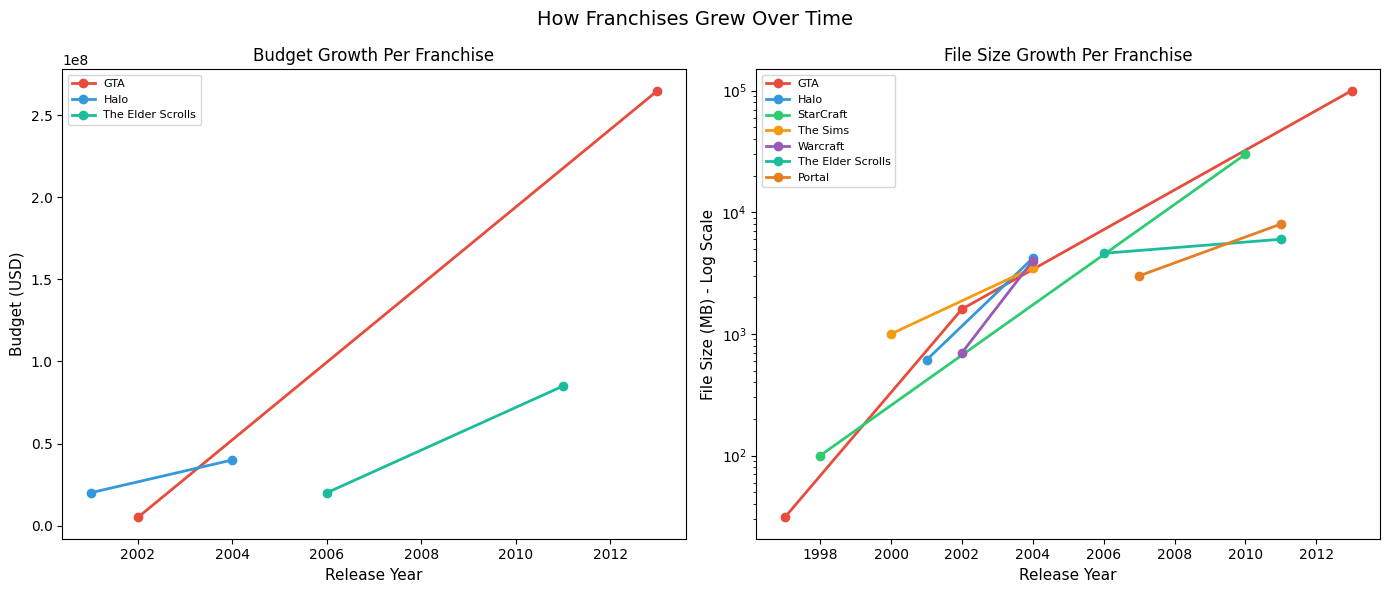

In [12]:
# Q5 - Franchise Growth Over Time
# Filter only franchises with 2+ entries
franchise_counts = df['franchise_name'].value_counts()
multi_entry = franchise_counts[franchise_counts >= 2].index.tolist()
multi_entry = [f for f in multi_entry if f != 'Standalone']

q5_df = df[df['franchise_name'].isin(multi_entry)]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22']

# Budget growth per franchise
ax = axes[0]
for i, franchise in enumerate(multi_entry):
    fdf = q5_df[q5_df['franchise_name'] == franchise].dropna(subset=['budget']).sort_values('release_year')
    if len(fdf) >= 2:
        ax.plot(fdf['release_year'], fdf['budget'], 
                marker='o', label=franchise, color=colors[i % len(colors)], linewidth=2)
ax.set_xlabel('Release Year', fontsize=11)
ax.set_ylabel('Budget (USD)', fontsize=11)
ax.set_title('Budget Growth Per Franchise', fontsize=12)
ax.legend(fontsize=8)

# File size growth per franchise
ax2 = axes[1]
for i, franchise in enumerate(multi_entry):
    fdf = q5_df[q5_df['franchise_name'] == franchise].dropna(subset=['file_size']).sort_values('release_year')
    if len(fdf) >= 2:
        ax2.plot(fdf['release_year'], fdf['file_size'], 
                 marker='o', label=franchise, color=colors[i % len(colors)], linewidth=2)
ax2.set_xlabel('Release Year', fontsize=11)
ax2.set_yscale('log')
ax2.set_ylabel('File Size (MB) - Log Scale', fontsize=11)
ax2.set_title('File Size Growth Per Franchise', fontsize=12)
ax2.legend(fontsize=8)

plt.suptitle('How Franchises Grew Over Time', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/charts/q5_franchise_growth.png', dpi=150)
plt.show()

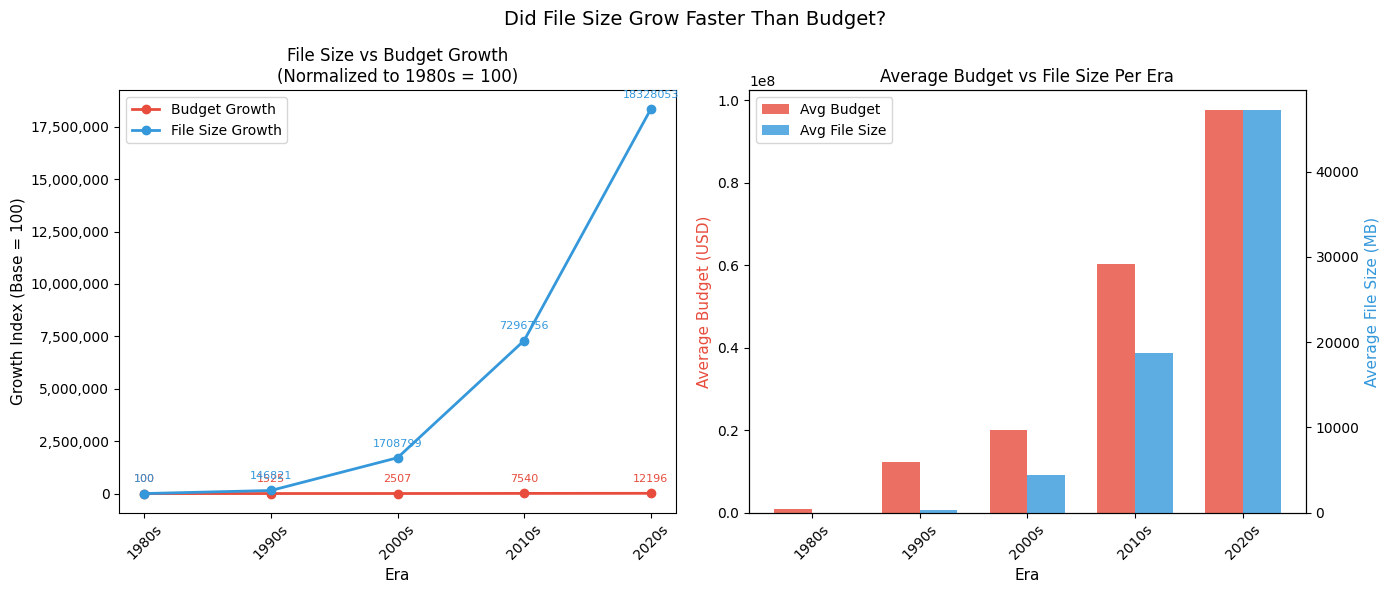

In [13]:
# Q6 - Normalized File Size vs Budget Growth Over Time
q6_budget = df.dropna(subset=['budget', 'release_year']).sort_values('release_year')
q6_file = df.dropna(subset=['file_size', 'release_year']).sort_values('release_year')

# Group by era and get averages
era_order = ['1980s', '1990s', '2000s', '2010s', '2020s']
avg_budget_era = q6_budget.groupby('era')['budget'].mean().reindex(era_order)
avg_file_era = q6_file.groupby('era')['file_size'].mean().reindex(era_order)

# Normalize to index 100 at first era
budget_normalized = (avg_budget_era / avg_budget_era.iloc[0]) * 100
file_normalized = (avg_file_era / avg_file_era.iloc[0]) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Normalized growth lines
axes[0].plot(era_order, budget_normalized.values, 
             marker='o', color='#e74c3c', linewidth=2, label='Budget Growth')
axes[0].plot(era_order, file_normalized.values, 
             marker='o', color='#3498db', linewidth=2, label='File Size Growth')
axes[0].set_xlabel('Era', fontsize=11)
axes[0].set_ylabel('Growth Index (Base = 100)', fontsize=11)
axes[0].set_title('File Size vs Budget Growth\n(Normalized to 1980s = 100)', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))
axes[0].tick_params(axis='x', rotation=45)

# Add value labels
for i, (b, f) in enumerate(zip(budget_normalized.values, file_normalized.values)):
    if not np.isnan(b):
        axes[0].annotate(f'{b:.0f}', (era_order[i], b), 
                        textcoords='offset points', xytext=(0, 8), 
                        ha='center', fontsize=8, color='#e74c3c')
    if not np.isnan(f):
        axes[0].annotate(f'{f:.0f}', (era_order[i], f), 
                        textcoords='offset points', xytext=(0, 8), 
                        ha='center', fontsize=8, color='#3498db')

# Supporting bar chart - average per era
x = np.arange(len(era_order))
width = 0.35
ax2 = axes[1]
ax2_twin = ax2.twinx()

bars1 = ax2.bar(x - width/2, avg_budget_era.values, width, 
                color='#e74c3c', alpha=0.8, label='Avg Budget')
bars2 = ax2_twin.bar(x + width/2, avg_file_era.values, width, 
                     color='#3498db', alpha=0.8, label='Avg File Size')

ax2.set_xlabel('Era', fontsize=11)
ax2.set_ylabel('Average Budget (USD)', fontsize=11, color='#e74c3c')
ax2_twin.set_ylabel('Average File Size (MB)', fontsize=11, color='#3498db')
ax2.set_xticks(x)
ax2.set_xticklabels(era_order, rotation=45)
ax2.set_title('Average Budget vs File Size Per Era', fontsize=12)

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.suptitle('Did File Size Grow Faster Than Budget?', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/charts/q6_filesize_vs_budget_growth.png', dpi=150)
plt.show()

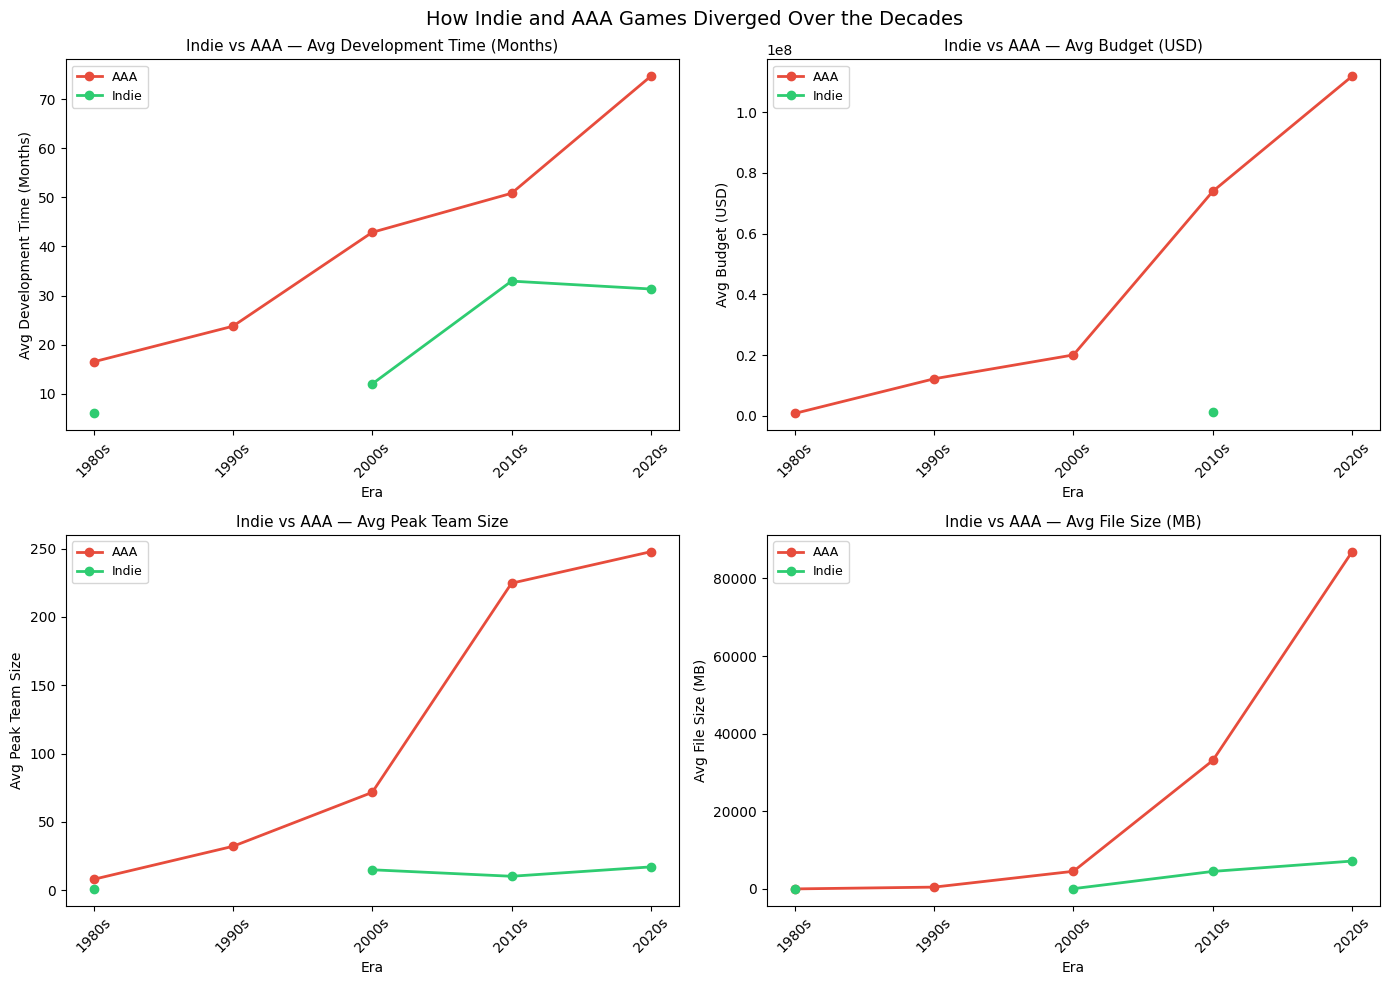

In [14]:
# Q8 - Indie vs AAA Divergence 2x2 Subplot Grid
q8_df = df[df['game_type'].isin(['Indie', 'AAA'])].copy()

era_order = ['1980s', '1990s', '2000s', '2010s', '2020s']

metrics = {
    'development_time': 'Avg Development Time (Months)',
    'budget': 'Avg Budget (USD)',
    'peak_team_size': 'Avg Peak Team Size',
    'file_size': 'Avg File Size (MB)'
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

colors = {'AAA': '#e74c3c', 'Indie': '#2ecc71'}

for i, (metric, label) in enumerate(metrics.items()):
    ax = axes[i]
    for game_type in ['AAA', 'Indie']:
        subset = q8_df[q8_df['game_type'] == game_type].dropna(subset=[metric])
        era_avg = subset.groupby('era')[metric].mean().reindex(era_order)
        ax.plot(era_order, era_avg.values, 
                marker='o', label=game_type, 
                color=colors[game_type], linewidth=2)
    
    ax.set_xlabel('Era', fontsize=10)
    ax.set_ylabel(label, fontsize=10)
    ax.set_title(f'Indie vs AAA — {label}', fontsize=11)
    ax.legend(fontsize=9)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('How Indie and AAA Games Diverged Over the Decades', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/charts/q8_indie_vs_aaa_divergence.png', dpi=150)
plt.show()

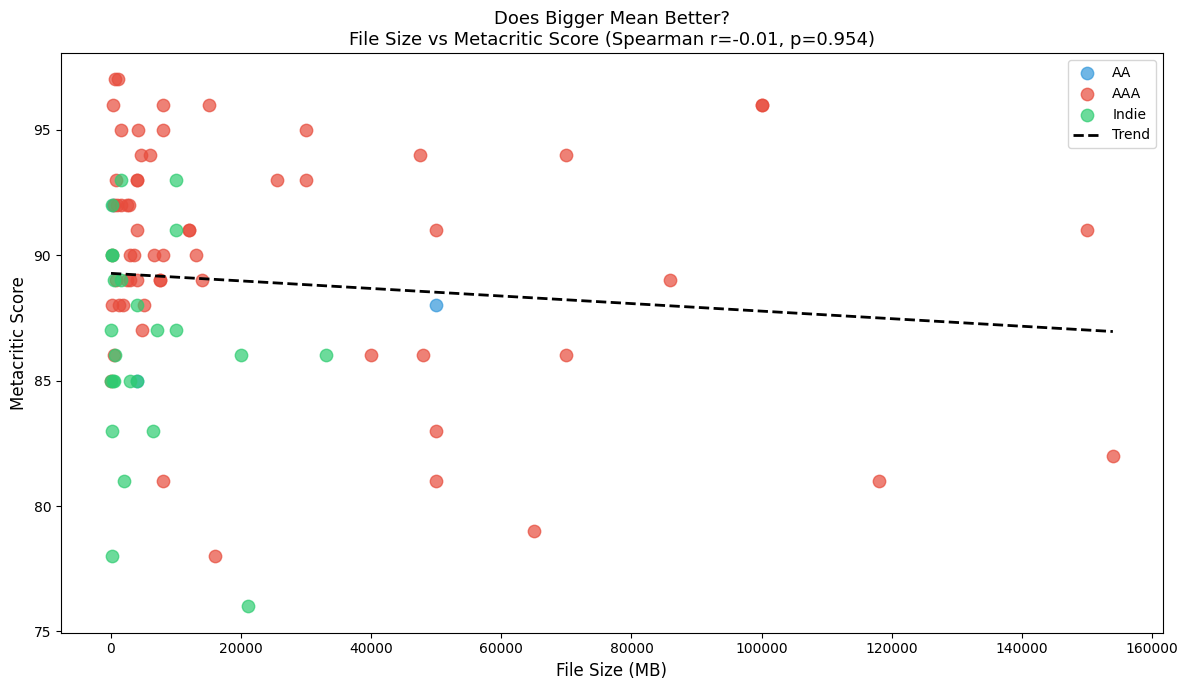


Spearman Correlation: -0.006
P-value: 0.954
Interpretation: Not Significant correlation


In [15]:
# Q9 - File Size vs Metacritic Score
q9_df = df.dropna(subset=['file_size', 'metacritic_score']).copy()

from scipy import stats

plt.figure(figsize=(12, 7))

colors = {'AAA': '#e74c3c', 'AA': '#3498db', 'Indie': '#2ecc71'}

for game_type, group in q9_df.groupby('game_type'):
    plt.scatter(group['file_size'], group['metacritic_score'],
                c=colors[game_type], label=game_type, alpha=0.7, s=80)

# Regression line
z = np.polyfit(q9_df['file_size'], q9_df['metacritic_score'], 1)
p = np.poly1d(z)
x_line = np.linspace(q9_df['file_size'].min(), q9_df['file_size'].max(), 100)
plt.plot(x_line, p(x_line), 'k--', linewidth=2, label='Trend')

# Spearman correlation
corr, pvalue = stats.spearmanr(q9_df['file_size'], q9_df['metacritic_score'])

plt.xlabel('File Size (MB)', fontsize=12)
plt.ylabel('Metacritic Score', fontsize=12)
plt.title(f'Does Bigger Mean Better?\nFile Size vs Metacritic Score (Spearman r={corr:.2f}, p={pvalue:.3f})', 
          fontsize=13)
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/charts/q9_filesize_vs_metacritic.png', dpi=150)
plt.show()

print(f"\nSpearman Correlation: {corr:.3f}")
print(f"P-value: {pvalue:.3f}")
print(f"Interpretation: {'Significant' if pvalue < 0.05 else 'Not Significant'} correlation")

In [16]:
conn = get_connection()
df = pd.read_sql_query("SELECT * FROM games", conn)
engines_df = pd.read_sql_query("SELECT * FROM engines", conn)
conn.close()

# Categorize engines in games dataset
def categorize_engine(engine):
    if 'Unreal' in str(engine):
        return 'Unreal'
    elif engine == 'Unity':
        return 'Unity'
    elif engine in ['Source Engine', 'GoldSrc', 'Source 1']:
        return 'Source'
    elif engine == 'Proprietary':
        return 'Proprietary'
    else:
        return 'Other Licensed'

df['engine_category'] = df['engine'].apply(categorize_engine)
print(df['engine_category'].value_counts())

engine_category
Proprietary       38
Other Licensed    34
Unreal            11
Unity             10
Source             7
Name: count, dtype: int64


/tmp/ipykernel_6988/1265833409.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=q7_df, x='engine_category', y='development_time',


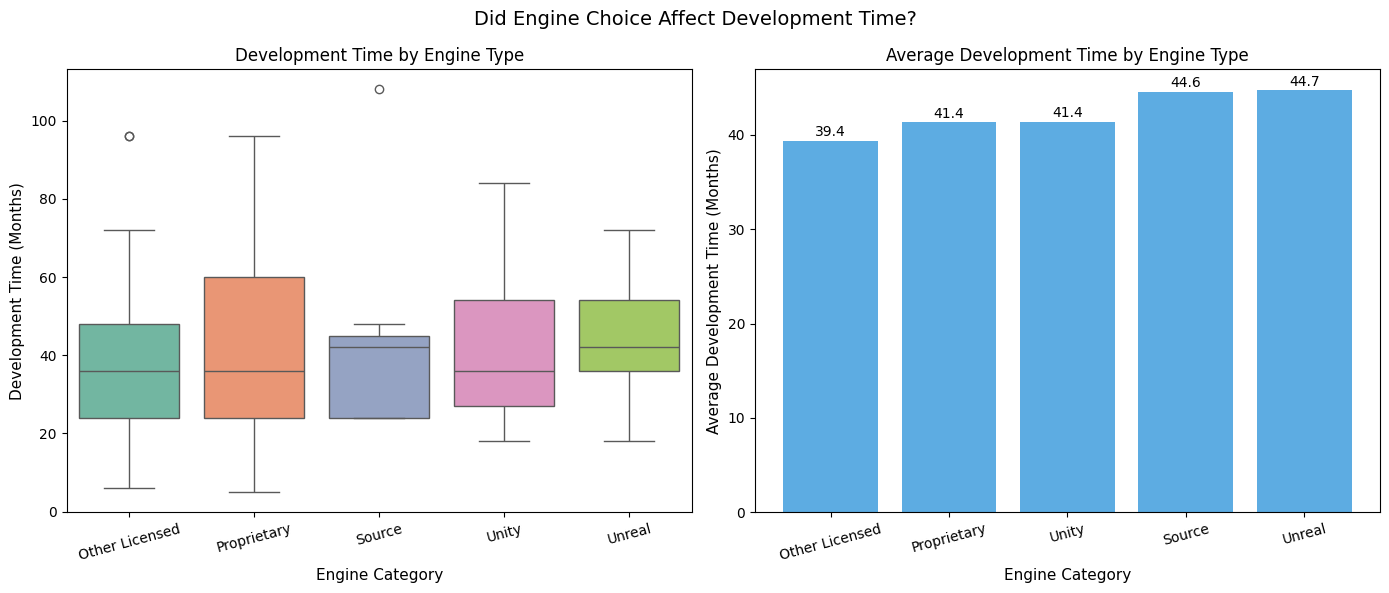


ANOVA Results:
F-statistic: 0.162
P-value: 0.957
Interpretation: No significant difference between engine types


In [17]:
# Q7 - Engine Type vs Development Time
q7_df = df.dropna(subset=['development_time'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Box Plot - Development Time per Engine Category
sns.boxplot(data=q7_df, x='engine_category', y='development_time',
            palette='Set2', ax=axes[0])
axes[0].set_title('Development Time by Engine Type', fontsize=12)
axes[0].set_xlabel('Engine Category', fontsize=11)
axes[0].set_ylabel('Development Time (Months)', fontsize=11)
axes[0].tick_params(axis='x', rotation=15)

# Bar Chart - Average Development Time per Engine Category
avg_dev = q7_df.groupby('engine_category')['development_time'].mean().sort_values()
axes[1].bar(avg_dev.index, avg_dev.values, color='#3498db', alpha=0.8)
for i, (idx, val) in enumerate(avg_dev.items()):
    axes[1].text(i, val + 0.5, f'{val:.1f}', ha='center', fontsize=10)
axes[1].set_title('Average Development Time by Engine Type', fontsize=12)
axes[1].set_xlabel('Engine Category', fontsize=11)
axes[1].set_ylabel('Average Development Time (Months)', fontsize=11)
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Did Engine Choice Affect Development Time?', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/charts/q7_engine_efficiency.png', dpi=150)
plt.show()

# ANOVA test
groups = [group['development_time'].values for name, group in q7_df.groupby('engine_category')]
f_stat, p_value = stats.f_oneway(*groups)
print(f"\nANOVA Results:")
print(f"F-statistic: {f_stat:.3f}")
print(f"P-value: {p_value:.3f}")
print(f"Interpretation: {'Significant difference' if p_value < 0.05 else 'No significant difference'} between engine types")